In [ ]:
!pip install preprocessing

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.6/349.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.6 MB/s eta 0:00:00
  Created wheel for nltk: filename=nltk-3.2.4-py3-none-any.whl size=1367709 sha256=02b6876457bfb4bc1a9097551c6b1c48c85f1c898183ea5b9abbde631fdca1f5
  Stored in directory: /root/.cache/pip/wheels/e0/86/87/be17eac066068c988d2a95b91808b475de507c64990cc93e36
Successfully built nltk
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
textblob 0.19.0 requires nltk>=3.9, but you have nltk 3.2.4 which is incompatible.


In [ ]:
#import library
import pandas as pd

#Read dataset
data=pd.read_csv('https://confrecordings.ams3.digitaloceanspaces.com/city_day.csv')

#Inspect the Data
print(data.head())
print(data.shape)
print(data.columns)
print(data.isnull().sum())


        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  
(29531, 16)
Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')
City    

In [ ]:
#Make copy of data and store in df1
df1 = data.copy()

#Handle missing values
df1['PM2.5']=df1['PM2.5'].fillna((df1['PM2.5'].median()))
df1['PM10']=df1['PM10'].fillna((df1['PM10'].median()))
df1['NO']=df1['NO'].fillna((df1['NO'].median()))
df1['NO2']=df1['NO2'].fillna((df1['NO2'].median()))
df1['NOx']=df1['NOx'].fillna((df1['NOx'].median()))
df1['NH3']=df1['NH3'].fillna((df1['NH3'].median()))
df1['CO']=df1['CO'].fillna((df1['CO'].median()))
df1['SO2']=df1['SO2'].fillna((df1['SO2'].median()))
df1['O3']=df1['O3'].fillna((df1['O3'].median()))
df1['Benzene']=df1['Benzene'].fillna((df1['Benzene'].median()))
df1['Toluene']=df1['Toluene'].fillna((df1['Toluene'].median()))
df1['Xylene']=df1['Xylene'].fillna((df1['Xylene'].median()))
df1['AQI']=df1['AQI'].fillna((df1['AQI'].median()))
df1['AQI_Bucket']=df1['AQI_Bucket'].fillna('Moderate')


from sklearn.preprocessing import LabelEncoder

#Load LabelEncoder and Apply on City and AQI_Bucket Column
le=LabelEncoder()
df1['City']=le.fit_transform(df1['City'].astype(str))
df1['AQI_Bucket']=le.fit_transform(df1['AQI_Bucket'].astype(str))
print(df1)


       City        Date  PM2.5   PM10     NO    NO2    NOx    NH3     CO  \
0         0  2015-01-01  48.57  95.68   0.92  18.22  17.15  15.85   0.92   
1         0  2015-01-02  48.57  95.68   0.97  15.69  16.46  15.85   0.97   
2         0  2015-01-03  48.57  95.68  17.40  19.30  29.70  15.85  17.40   
3         0  2015-01-04  48.57  95.68   1.70  18.48  17.97  15.85   1.70   
4         0  2015-01-05  48.57  95.68  22.10  21.42  37.76  15.85  22.10   
...     ...         ...    ...    ...    ...    ...    ...    ...    ...   
29526    25  2020-06-27  15.02  50.94   7.68  25.06  19.54  12.47   0.47   
29527    25  2020-06-28  24.38  74.09   3.42  26.06  16.53  11.99   0.52   
29528    25  2020-06-29  22.91  65.73   3.45  29.53  18.33  10.71   0.48   
29529    25  2020-06-30  16.64  49.97   4.05  29.26  18.80  10.03   0.52   
29530    25  2020-07-01  15.00  66.00   0.40  26.85  14.05   5.20   0.59   

         SO2      O3  Benzene  Toluene  Xylene    AQI  AQI_Bucket  
0      27.64  133.3

In [ ]:
#Create a copy of df1 dataframe
df = df1.copy()

#Create new column called Vehicular Pollution Content
df['Vehicular Pollution content'] = df['PM2.5']+df['PM10']+df['NO']+df['NO2']+df['NOx']+df['NH3']+df['CO']

#Create new column called Industrial Pollution Content
df['Industrial Pollution content'] = df['SO2']+df['O3']+df['Benzene']+df['Toluene']+df['Xylene']

#Drop rows
df = df.drop(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3','Benzene','Toluene','Xylene'],axis=1)

#Print summary of row
print(df.info())

#Print top 5 rows of df
print(df.head())

#Create a new dataframe called data with three columns
data=df[['City','Vehicular Pollution content','Industrial Pollution content']]


#Print top 5 rows of data
print(data.head())

#scale the data and print scaled data
from sklearn import preprocessing
x_scaled = preprocessing.scale(data)
print(x_scaled)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   City                          29531 non-null  int64  
 1   Date                          29531 non-null  object 
 2   AQI                           29531 non-null  float64
 3   AQI_Bucket                    29531 non-null  int64  
 4   Vehicular Pollution content   29531 non-null  float64
 5   Industrial Pollution content  29531 non-null  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 1.4+ MB
None
   City        Date    AQI  AQI_Bucket  Vehicular Pollution content  \
0     0  2015-01-01  118.0           1                       197.31   
1     0  2015-01-02  118.0           1                       194.19   
2     0  2015-01-03  118.0           1                       243.90   
3     0  2015-01-04  118.0           1                       199.95  

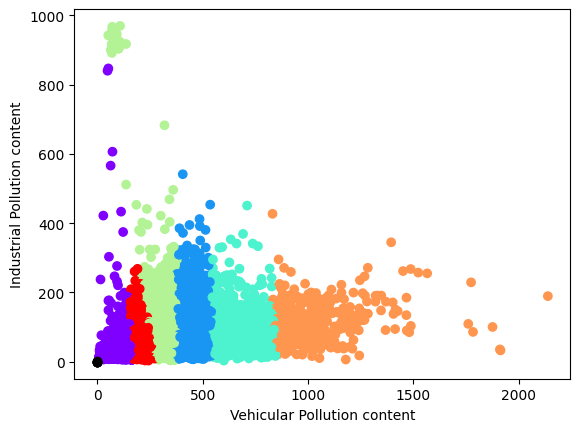

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#Load the KMeans dataset and Train with x_scaled data
kmeans = KMeans(6)
kmeans.fit(x_scaled)
centroids = kmeans.cluster_centers_
cluster_new=data.copy()
cluster_new['new_cluster_pred'] = kmeans.fit_predict(cluster_new)

#Plot a scatterplot
plt.scatter(cluster_new['Vehicular Pollution content'], cluster_new['Industrial Pollution content'], c=cluster_new['new_cluster_pred'], cmap='rainbow')
plt.scatter(centroids[:,0], centroids[:,1],color='black')
plt.xlabel('Vehicular Pollution content')
plt.ylabel('Industrial Pollution content')
plt.show()



In [ ]:
import pandas as pd
df1=pd.read_csv('https://confrecordings.ams3.digitaloceanspaces.com/clean_code.csv')
print(df1.head())


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

#select dependent and independent column
y = df1['AQI_Bucket']
x = df1[['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2','O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']]

#Split data into training and testing model
X_train,X_test ,y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 0)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

#Load SVC, Train the model and predict X_test
cls=SVC()
cls.fit(X_train,y_train)
svmpred=cls.predict(X_test)
print(svmpred)

#print confusion metrics
cm=confusion_matrix(y_test,svmpred)
print("confussion matrix")
print(cm)

#print(accuracy)
print("\n")
accuracy=accuracy_score(y_test,svmpred)
print("accuracy",accuracy*100)

   City        Date  PM2.5   PM10     NO    NO2    NOx    NH3     CO    SO2  \
0     0  01-01-2015  48.57  95.68   0.92  18.22  17.15  15.85   0.92  27.64   
1     0  02-01-2015  48.57  95.68   0.97  15.69  16.46  15.85   0.97  24.55   
2     0  03-01-2015  48.57  95.68  17.40  19.30  29.70  15.85  17.40  29.07   
3     0  04-01-2015  48.57  95.68   1.70  18.48  17.97  15.85   1.70  18.59   
4     0  05-01-2015  48.57  95.68  22.10  21.42  37.76  15.85  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI  AQI_Bucket  
0  133.36     0.00     0.02    0.00  118           1  
1   34.06     3.68     5.50    3.77  118           1  
2   30.70     6.80    16.40    2.25  118           1  
3   36.08     4.43    10.14    1.00  118           1  
4   39.31     7.01    18.89    2.78  118           1  
(20671, 14)
(8860, 14)
(20671,)
(8860,)
[5 1 1 ... 3 1 2]
confussion matrix
[[ 352    0    0   41    0    0]
 [   0 4101    3   13    0    0]
 [   0   15  809    0    0   17]
 [   2   16    0 240